## Preparation

### Libraries import & metadata storage definitions

In [31]:
import os
import pandas as pd
import numpy as np
from crowdkit.aggregation import DawidSkene

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Элина\Desktop\Вузовские работы (магистратура)\1,2,3 CV,Осн.ML,NLP,Прак.ML\ML_homeworks_magistracy\.mlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
contents_folder = "task_files_3"
checkpoint_dir = os.path.join(contents_folder, "checkpoints")
graph_dir = os.path.join(contents_folder, "graphs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common functions

In [4]:
def rates_histplot_all(rates: pd.DataFrame,
                       with_kde: bool = True,
                       n_bins: int = 10):
    fig, ax = plt.subplots(figsize=(5, 3))

    sns.histplot(data=rates.to_numpy().flatten(), kde=with_kde, bins=n_bins)
    ax.set(
        title="Rates distribution over all pages",
        xlabel="Rate"
    )

    ax.grid(True, alpha=0.3, zorder=0)
    plt.show()    


def rates_histplot_pages(rates: pd.DataFrame,
                         with_kde: bool = True,
                         n_bins: int = 10):
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

    for i, column in enumerate(rates.columns):
        sns.histplot(data=rates, x=column, kde=with_kde, ax=axes[i], color=f'C{i}', element="step", bins=n_bins)
        axes[i].set(
            title=f"{column}",
            xlabel="Rate"
        )
        if i:
            axes[i].set_ylabel("")
        axes[i].grid(True, alpha=0.3, zorder=0)

    plt.suptitle("Rates distribution over pages", fontsize=16)
    plt.tight_layout()
    plt.show()

### Manual assessment analysis

In [5]:
man_rates_path = os.path.join(contents_folder, "requests_orig_rate.csv")
man_rates = pd.read_csv(man_rates_path, names=[f"{i+1}_page" for i in range(5)])
man_rates

,1_page,2_page,3_page,4_page,5_page
0,1.00,0.10,0.60,0.85,0.70
1,0.13,0.10,0.20,0.10,0.00
2,0.30,0.30,0.00,0.15,0.00
3,0.20,0.93,0.90,0.93,0.90
4,0.95,0.30,0.12,0.10,0.10
5,0.85,0.00,0.30,0.65,0.35
6,0.55,0.85,0.55,0.37,0.10
7,1.00,0.50,0.50,0.50,0.50
8,0.95,0.30,0.90,0.87,0.97
9,0.90,0.70,0.70,1.00,0.80


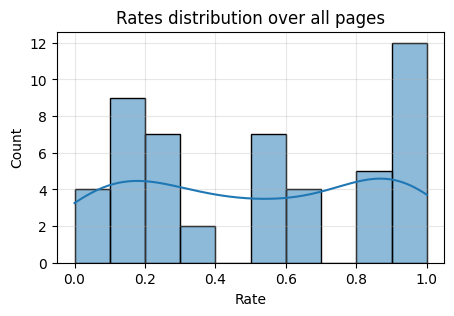

In [6]:
rates_histplot_all(man_rates)

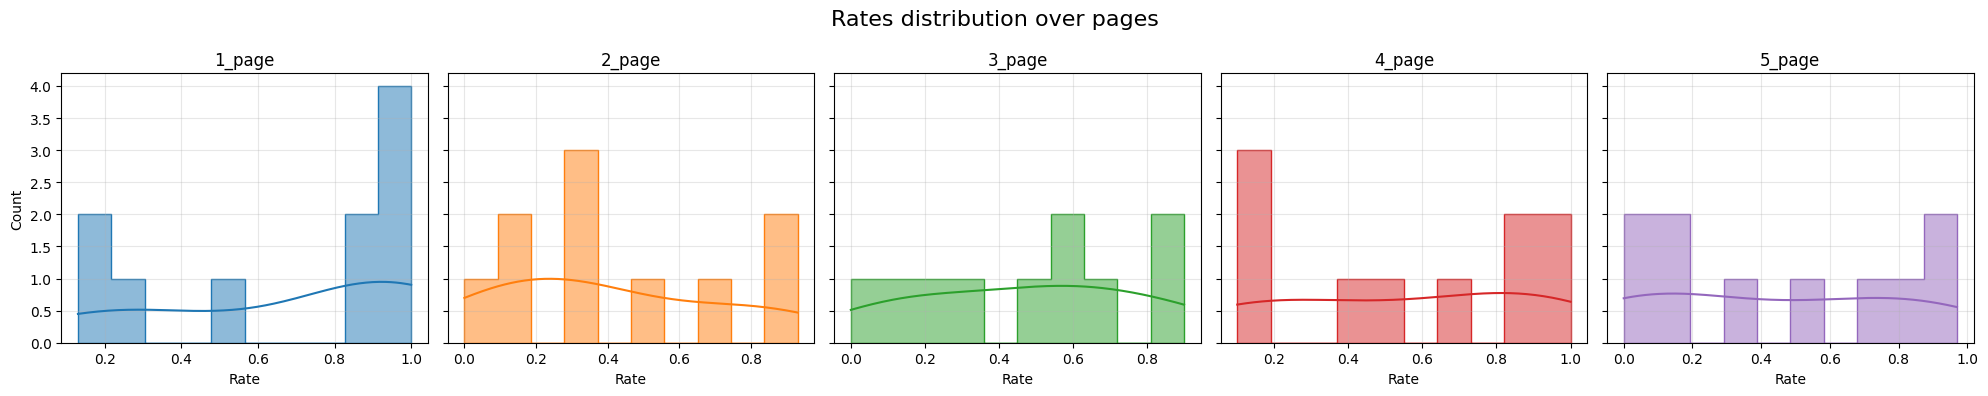

In [7]:
rates_histplot_pages(man_rates)

The rates can be considered uniformly distributed, so the following "assessors" rates will be sampled from $\mathcal{U}[0; 1]$. 

## Assessors rating modelling

### Main constants & functions

In [8]:
n_pages = 5
n_good_assessors = 8500
n_bad_assessors = 1000
n_frauders = 500

lower_b = 0
upper_b = 0

In [9]:
def generate_rates(n_pages: int,
                   n_assessors: int,
                   distribution,
                   *args):
    rates_dict = {}
    for i in range(n_pages):
        column_name = f"Page_{i+1}"
        rates_dict[column_name] = distribution(size=n_assessors, *args)

    return cut_distribution(pd.DataFrame(rates_dict).astype(float), 0, 1)

def cut_distribution(rates: pd.DataFrame,
                     lower_b: float = 0.0,
                     upper_b: float = 1.0):
    return rates.mask(rates < lower_b, lower_b).mask(rates > upper_b, upper_b)

### Rates dataset creation

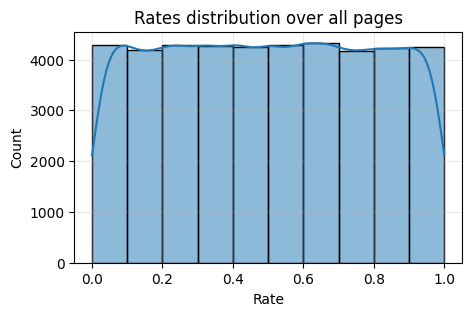

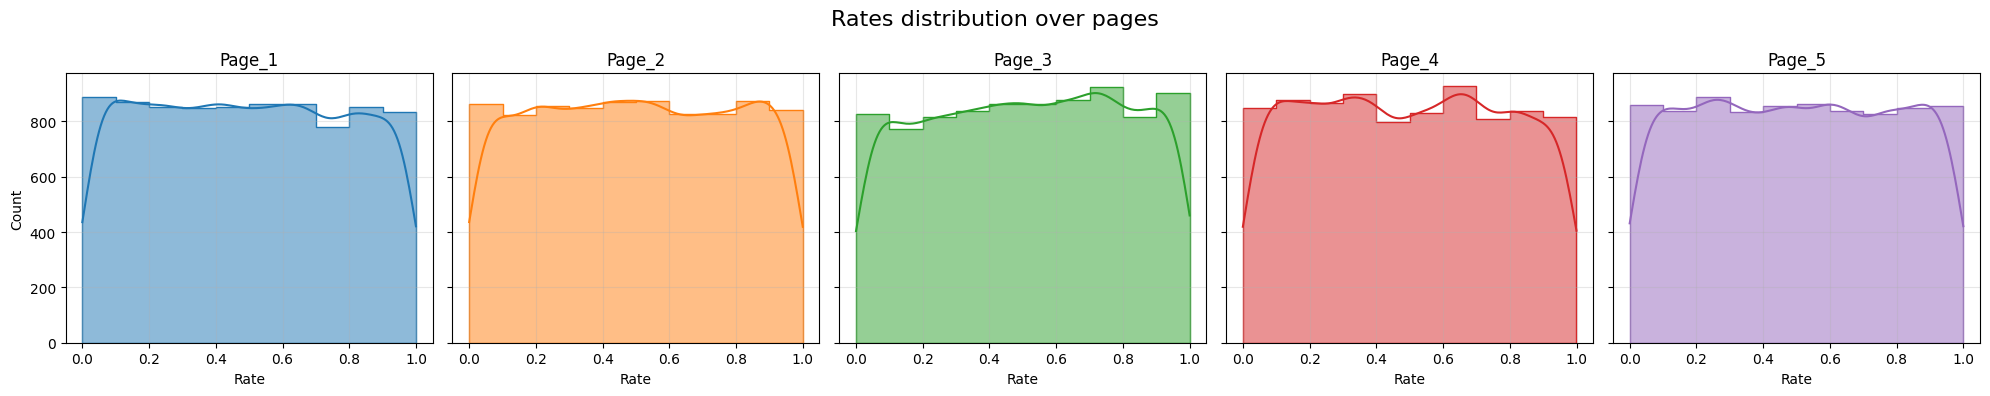

In [10]:
np.random.seed(42)

rates = generate_rates(n_pages, n_good_assessors, np.random.uniform, 0, 1)
rates_histplot_all(rates)
rates_histplot_pages(rates)

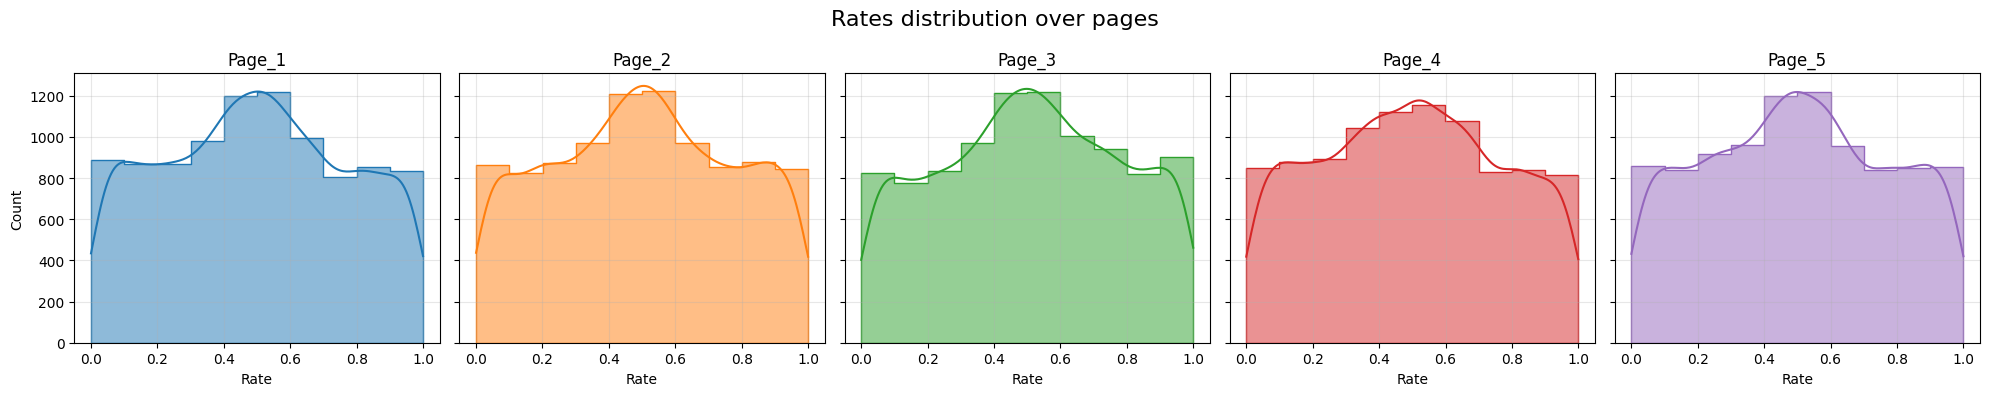

In [11]:
np.random.seed(42)

rates = pd.concat((rates, 
                   generate_rates(n_pages, n_bad_assessors, np.random.normal, 0.5, 0.1)))
rates_histplot_pages(rates)

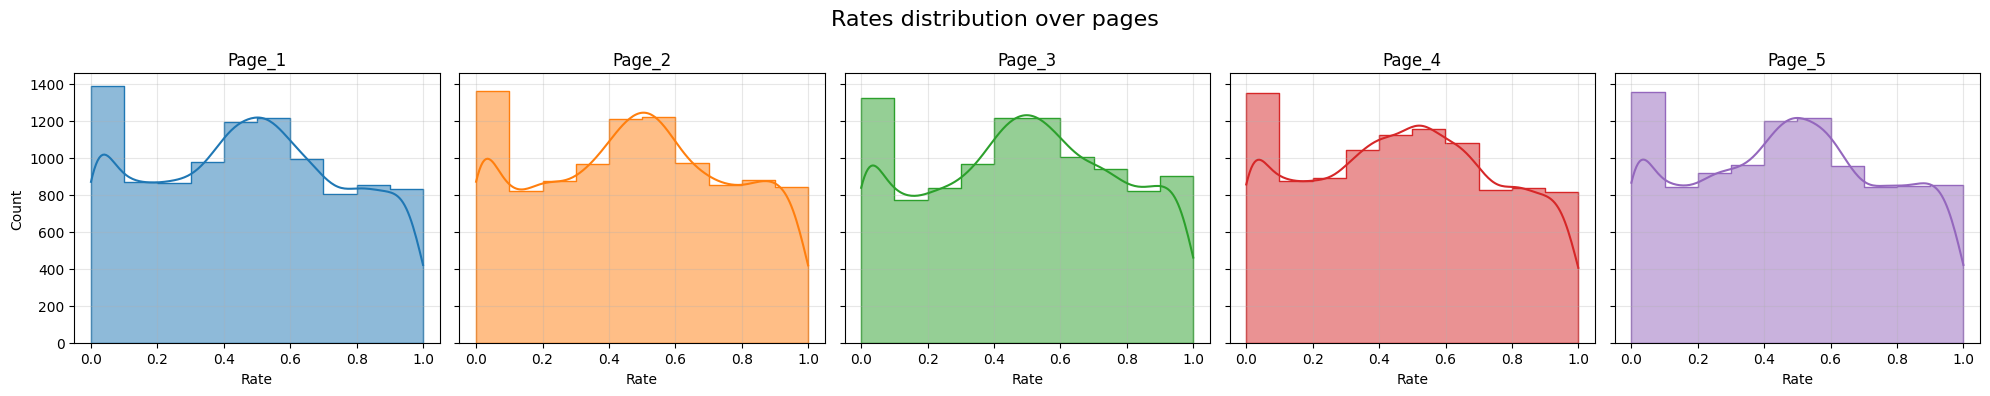

In [12]:
np.random.seed(42)

rates = pd.concat((rates, 
                   generate_rates(n_pages, n_frauders, np.random.randint, 0, 1)))
rates_histplot_pages(rates)

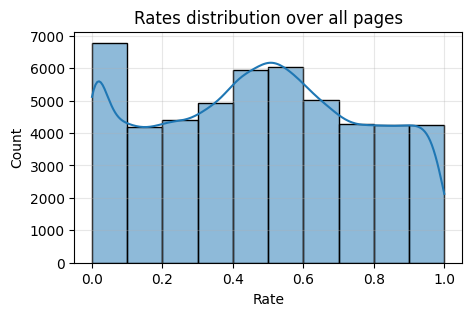

In [24]:
np.random.seed(42)

rates = rates.sample(frac=1).reset_index(drop=True)
rates_histplot_all(rates)

## Dawid-Skene implementation

In [17]:
def discretize_rates(rates: pd.DataFrame,
                     n_bins: int = 10):
    rates_discrete = rates.copy()
    for column in rates_discrete.columns:
        rates_discrete[column] = pd.cut(
            rates_discrete[column], 
            bins=n_bins, 
            right=True, 
            include_lowest=True,
            labels=range(n_bins)
        )
    return rates_discrete

In [25]:
rates_discrete = discretize_rates(rates, n_bins=10)
rates_discrete.head(4)

,Page_1,Page_2,Page_3,Page_4,Page_5
0,7,7,1,6,2
1,6,0,2,4,0
2,1,9,8,3,3
3,2,4,9,9,5


In [26]:
rates.head(4)

,Page_1,Page_2,Page_3,Page_4,Page_5
0,0.714702,0.757812,0.168981,0.629181,0.260259
1,0.693210,0.042591,0.237063,0.493193,0.088598
2,0.182813,0.909041,0.814607,0.397271,0.305169
3,0.285206,0.489272,0.927185,0.981220,0.581537


In [33]:
rates_longed_list = []
for assess_id, assess_rates in rates_discrete.iterrows():
    for page_id, page_name in enumerate(rates_discrete.columns):
        rates_longed_list.append({"worker": assess_id,
                                  "task": page_id, 
                                  "label": assess_rates[page_name]})

rates_longed = pd.DataFrame(rates_longed_list)

In [ ]:
dawid_skene = DawidSkene(n_iter=100)
dawid_skene.fit(rates_longed)

aggregated_labels = dawid_skene.probas_.idxmax(axis=1)
assessor_errors = dawid_skene.errors_

In [36]:
aggregated_labels

task
0    1
1    8
2    7
3    6
4    2
dtype: int64

In [42]:
assessor_errors.head(10)

0             1             2     3     4     5  \
worker label                                                       
0      7      0.25  1.000000e+00  1.000000e-10  0.25  0.25  0.25   
       1      0.25  1.000000e-10  1.000000e-10  0.25  0.25  0.25   
       6      0.25  1.000000e-10  1.000000e-10  0.25  0.25  0.25   
       2      0.25  1.000000e-10  1.000000e+00  0.25  0.25  0.25   
1      6      0.25  1.000000e+00  1.000000e-10  0.25  0.25  0.25   
       0      0.25  1.000000e-10  1.000000e+00  0.25  0.25  0.25   
       2      0.25  1.000000e-10  1.000000e-10  0.25  0.25  0.25   
       4      0.25  1.000000e-10  1.000000e-10  0.25  0.25  0.25   
2      1      0.25  1.000000e+00  1.000000e-10  0.25  0.25  0.25   
       9      0.25  1.000000e-10  1.000000e-10  0.25  0.25  0.25   

                         6             7             8     9  
worker label                                                  
0      7      1.000000e-10  1.000000e-10  1.000000e+00  0.25  
       1      1.000000e-10  1.000000e+00  1.000000e-10  0.25  
       6      1.000000e+00  1.000000e-10  1.000000e-10  0.25  
       2      1.000000e-10  1.000000e-10  1.000000e-10  0.25  
1      6      1.000000e-10  1.000000e-10  1.000000e-10  0.25  
       0      1.000000e-10  1.000000e-10  1.000000e+00  0.25  
       2      1.000000e-10  1.000000e+00  1.000000e-10  0.25  
       4      1.000000e+00  1.000000e-10  1.000000e-10  0.25  
2      1      1.000000e-10  1.000000e-10  1.000000e-10  0.25  
       9      1.000000e-10  1.000000e-10  1.000000e+00  0.25

In [ ]:
for page_name in rates_discrete.columns:
    print(f"Error matrix for assessor {assessor}:")
    print(assessor_errors[int(assessor.split('_')[1]) - 1])
    print("\n" + "-"*50 + "\n")

ValueError: invalid literal for int() with base 10: 'Page'

In [ ]:
assessor_confidence = {}
for assessor in rates_discrete.columns:
    assessor_idx = int(assessor.split('_')[0]) - 1
    confusion_matrix = assessor_errors[assessor_idx]
    accuracy = np.diag(confusion_matrix).sum() / confusion_matrix.sum()
    assessor_confidence[assessor] = accuracy

print("Оценка доверия к асессорам (на основе точности):")
for assessor, confidence in assessor_confidence.items():
    print(f"{assessor}: {confidence:.4f}")